<div>
<img src="https://www.cosmos.esa.int/documents/3414525/0/Logo_Gaia_may_23_2022.png/cf6be61e-609e-27dc-3ad6-03ac5209bdc4?t=1653299950248" width="300" align="right"/>
</div>

# Tutorial:  Retrieve (all) the DataLink products associated to a sample

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />


---
Copyright (c) European Space Agency, 2025.

This file is subject to the terms and conditions defined in file **[LICENSE.txt](LICENSE.txt)**, which
is part of this source code package. No part of the package, including
this file, may be copied, modified, propagated, or distributed except according to
the terms contained in the file **[LICENSE.txt](LICENSE.txt)**.

---



**Release number:** 
v1.2 (2025-05-30)


**Applicable Gaia Data Releases:**
Gaia EDR3, Gaia DR3


**Summary:** 

This code shows how to retrieve the different DataLink products from an input list of Gaia DR3 sources. These products are serialised in two different data structures:
* INDIVIDUAL (that follows the [IVOA](https://www.ivoa.net) data model recommendations whenever possible), and
* RAW (the internal format used by the [Gaia collaboration](https://www.cosmos.esa.int/web/gaia/dpac/consortium).

Both data structures contain virtually the same information. This notebook shows how to access to the data and metadata of the products retrieved in INDIVIDUAL data structure. For simplicity, the files are downloaded in [VOTable](https://www.ivoa.net/documents/VOTable/20191021/) format (to have an overview
of the serialisation options of the DataLink products served by the Gaia ESA Archive please read the [DataLink products serialisation tutorial](https://www.cosmos.esa.int/web/gaia-users/archive/datalink-products#datalink_serialisation)).



**Useful URLs:**

* [Questions or suggestions](https://www.cosmos.esa.int/web/gaia/questions)
* [Tutorials, documentation, and more](https://www.cosmos.esa.int/web/gaia-users/archive)
* [Known issues in the Gaia data](https://www.cosmos.esa.int/web/gaia-users/known-issues)
* [Gaia data credits and acknowledgements](https://www.cosmos.esa.int/web/gaia-users/credits)
* [GaiaXPy](https://gaia-dpci.github.io/GaiaXPy-website/): GaiaXPy is a Python library to facilitate handling Gaia BP/RP spectra as distributed from the Gaia archive.
* [Astropy: VOTable XML handling](https://docs.astropy.org/en/stable/io/votable/index.html) 

In [8]:
from astroquery.gaia import Gaia
import matplotlib.pyplot as plt

In [2]:
def plot_e_phot(inp_table, colours  = ['green', 'red', 'blue'], title = '', fontsize = 12, show_legend = True, show_grid = True, figsize = [20,5]):
    ""
    "Epoch photometry plotter. 'inp_table' MUST be an Astropy-table object."
    ""       
    fig       = plt.figure(figsize=figsize)
    time_zero = 2455197.5 # See: https://gea.esac.esa.int/archive/documentation/GDR3/Gaia_archive/chap_datamodel/sec_dm_photometry/ssec_dm_epoch_photometry.html#epoch_photometry-g_transit_time
    xlabel    = f'JD date [TCB - {time_zero}]'
    ylabel    = f'magnitude'
    
    plt.gca().invert_yaxis()
    plt.plot(inp_table['g_transit_time'], inp_table['g_transit_mag'], 'o', label = 'G',  color = 'green')
    plt.plot(inp_table['bp_obs_time'],    inp_table['bp_mag'],        'o', label = 'BP', color = 'blue')
    plt.plot(inp_table['rp_obs_time'],    inp_table['rp_mag'],        'o', label = 'RP', color = 'red')
    make_canvas(title = title, xlabel = xlabel, ylabel = ylabel, fontsize= fontsize, show_legend=show_legend, show_grid = show_grid)
    plt.show()


def plot_sampled_spec(inp_table, color = 'blue', title = '', fontsize = 14, show_legend = True, show_grid = True, linewidth = 2, figsize = [20,5], show_plot = True):
    ""
    "RVS & XP sampled spectrum plotter. 'inp_table' MUST be an Astropy-table object."
    ""       
    if show_plot:
        fig      = plt.figure(figsize=figsize)
    xlabel   = f'Wavelength [{inp_table["wavelength"].unit}]'
    ylabel   = f'Flux [{inp_table["flux"].unit}]'
    plt.plot(inp_table['wavelength'], inp_table['flux'], '-', linewidth = linewidth)
    make_canvas(title = title, xlabel = xlabel, ylabel = ylabel, fontsize= fontsize, show_legend=False, show_grid = show_grid)
    if show_plot:
        plt.show()


def make_canvas(title = '', xlabel = '', ylabel = '', show_grid = False, show_legend = False, fontsize = 12):
    ""
    "Create generic canvas for plots"
    ""
    plt.title(title,    fontsize = fontsize)
    plt.xlabel(xlabel,  fontsize = fontsize)
    plt.ylabel(ylabel , fontsize = fontsize)
    plt.xticks(fontsize = fontsize)
    plt.yticks(fontsize = fontsize)
    if show_grid:
        plt.grid()
    if show_legend:
        plt.legend(fontsize = fontsize*1.25)

## Connect to the Gaia Archive

The DataLink products are available to both registered & anonymous users. However, we recommend to access as a registered user due to their extra benefits when executing long queries (as explained in this [FAQ](https://www.cosmos.esa.int/web/gaia-users/archive/faq#account-limits-2020)).

In [3]:
Gaia.login()

INFO: Login to gaia TAP server [astroquery.gaia.core]


User:  hcanovas
Password:  ········


INFO: OK [astroquery.utils.tap.core]
INFO: Login to gaia data server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]


##  Download data sample

The query below retrieves a random sample of Gaia (E)DR3 sources having all types of DataLink products.

In [4]:
query = f"SELECT source_id, ra, dec, pmra, pmdec, parallax \
FROM gaiadr3.gaia_source \
WHERE has_epoch_photometry = 'True' \
AND has_xp_sampled = 'True'\
AND has_rvs = 'True' \
AND has_mcmc_msc = 'True' \
AND has_mcmc_gspphot = 'True' \
AND random_index between 0 and 200000"


job     = Gaia.launch_job_async(query)
results = job.get_results()
print(f'Table size (rows): {len(results)}')
results

INFO: Query finished. [astroquery.utils.tap.core]
Table size (rows): 3


source_id,ra,dec,pmra,pmdec,parallax
,deg,deg,mas / yr,mas / yr,mas
int64,float64,float64,float64,float64,float64
6196457933368101888,202.80436078238418,-21.178991138861807,80.54562044679744,-32.95247075512294,10.167137280246173
5924045608237672448,257.635024432604,-53.35065341915946,-4.404105752618793,-6.63122508730231,0.19938320884996538
4911590910260264960,24.783541498908786,-55.317468647500505,40.64757827861938,10.758104689073546,6.2453699013330555


## Download  DataLink Products: INDIVIDUAL

The example below retrieves ALL available DataLink products for the input sample of Gaia Source IDs. This option significantly increases the total download time, and here it is selected only for teaching purposes. If you are not interested in downloading all products we recommend you to specify the DataLink product in ```retrieval_type```.

The downloaded files can be stored locally by specifying the output file directory via the ```output_file``` option in the ```load_data``` method below. Note that:
* The DataLink products are stored in a .gz compressed directory. To avoid errors, this shoud be considered when naming the output file, e.g., ```output_file = 'datalink_output.gz'```
* The individual files will also be saved in the same directory from where this notebook is being launched. This is a known bug and we are working to fix it.

In [5]:
retrieval_type = 'ALL'          # Options are: 'EPOCH_PHOTOMETRY', 'MCMC_GSPPHOT', 'MCMC_MSC', 'XP_SAMPLED', 'XP_CONTINUOUS', 'RVS', 'ALL'
data_structure = 'INDIVIDUAL'   # Options are: 'INDIVIDUAL' and 'RAW'
data_release   = 'Gaia DR3'     # Options are: 'Gaia DR3' (default), 'Gaia DR2'


datalink = Gaia.load_data(ids=results['source_id'], data_release = data_release, retrieval_type=retrieval_type, data_structure = data_structure, verbose = False)
dl_keys  = [inp for inp in datalink.keys()]
dl_keys.sort()

print()
print(f'The following Datalink products have been downloaded:')
print('-' * 160)

for dl_key in dl_keys:
    print(f' * {dl_key}')


The following Datalink products have been downloaded:
----------------------------------------------------------------------------------------------------------------------------------------------------------------
 * EPOCH_PHOTOMETRY-Gaia DR3 4911590910260264960.xml
 * EPOCH_PHOTOMETRY-Gaia DR3 5924045608237672448.xml
 * EPOCH_PHOTOMETRY-Gaia DR3 6196457933368101888.xml
 * MCMC_GSPPHOT-Gaia DR3 4911590910260264960.xml
 * MCMC_GSPPHOT-Gaia DR3 5924045608237672448.xml
 * MCMC_GSPPHOT-Gaia DR3 6196457933368101888.xml
 * MCMC_MSC-Gaia DR3 4911590910260264960.xml
 * MCMC_MSC-Gaia DR3 5924045608237672448.xml
 * MCMC_MSC-Gaia DR3 6196457933368101888.xml
 * RVS-Gaia DR3 4911590910260264960.xml
 * RVS-Gaia DR3 5924045608237672448.xml
 * RVS-Gaia DR3 6196457933368101888.xml
 * XP_CONTINUOUS-Gaia DR3 4911590910260264960.xml
 * XP_CONTINUOUS-Gaia DR3 5924045608237672448.xml
 * XP_CONTINUOUS-Gaia DR3 6196457933368101888.xml
 * XP_SAMPLED-Gaia DR3 4911590910260264960.xml
 * XP_SAMPLED-Gaia DR3 592

### Detailed content

The DataLink products are stored inside a Python Dictionary. Each element (key) of the dictionary consist in a 1-element list that contains a [VOTable XML](https://docs.astropy.org/en/stable/io/votable/index.html) file.
This file contains both useful data and metadata that can be examined as explained below (see for details the [DataLink: Products serialisation tutorial](https://www.cosmos.esa.int/web/gaia-users/archive/datalink-products#datalink_serialisation)).
The example below shows how to inspect (and plot) the content of different products - feel free to play with the code to explore the different options available.

Note that the time unit for the epoch photometry product is Barycentric JD in TCB −2455197.5 (day) (see the corresponding [DataModel chapter](https://gea.esac.esa.int/archive/documentation/GDR3/Gaia_archive/chap_datamodel/sec_dm_photometry/ssec_dm_epoch_photometry.html#epoch_photometry-g_transit_time))

File metadata:
----------------------------------------------------------------------------------------------------------------------------------------------------------------
<PARAM ID="solution_id" datatype="long" name="solution_id" ucd="meta.version" value="375316653866487564"/>
<PARAM ID="source_id" datatype="long" name="source_id" ucd="meta.id;meta.main" value="4911590910260264960"/>
<FIELD ID="transit_id" datatype="long" name="transit_id" ucd="meta.id"/>
<FIELD ID="g_transit_time" datatype="double" name="g_transit_time" ref="time_frame" ucd="time.epoch" unit="d" utype="spec:Spectrum.Data.TimeAxis.Value"/>
<FIELD ID="g_transit_flux" datatype="double" name="g_transit_flux" ucd="phot.flux;em.opt" unit="electron / s" utype="spec:Spectrum.Data.SpectralAxis.Value"/>
<FIELD ID="g_transit_flux_error" datatype="double" name="g_transit_flux_error" ucd="stat.error;phot.flux;em.opt" unit="electron / s"/>
<FIELD ID="g_transit_flux_over_error" datatype="float" name="g_transit_flux_over_error" 

transit_id,g_transit_time,g_transit_flux,g_transit_flux_error,g_transit_flux_over_error,g_transit_mag,bp_obs_time,bp_flux,bp_flux_error,bp_flux_over_error,bp_mag,rp_obs_time,rp_flux,rp_flux_error,rp_flux_over_error,rp_mag,variability_flag_g_reject,variability_flag_bp_reject,variability_flag_rp_reject,g_other_flags,bp_other_flags,rp_other_flags,rejected_by_photometry
,d,electron / s,electron / s,,mag,d,electron / s,electron / s,,mag,d,electron / s,electron / s,,mag,,,,,,,
int64,float64,float64,float64,float32,float64,float64,float64,float64,float32,float64,float64,float64,float64,float32,float64,bool,bool,bool,int64,int64,int64,bool
14922212505719965,1666.7066178487407,414993.78049738676,487.08184643327724,852.0001,11.642262897057917,1666.706924867667,199352.02416028673,243.10506798363699,820.0242,12.089490591507708,1666.7070100568133,304486.59318223904,277.650662825362,1096.6536,11.038975063618746,False,False,False,4097,0,0,False
14936045572629106,1666.9567829719524,415223.6152432905,756.6865282971511,548.73926,11.641661753520346,1666.9570978731522,198827.86089921332,234.5247765447549,847.7904,12.09234911540527,1666.9571841362197,304275.1443979558,273.45150733390045,1112.7207,11.039729308163398,False,False,False,4609,0,0,False
14945786367190460,1667.132946715427,412579.85777377436,264.43392219174564,1560.238,11.648596812514562,1667.1332616640113,409389.33978470624,339.71967650240606,1205.0798,11.308200891433074,1667.133347609519,407707.1616243589,321.11383421937455,1269.6655,10.722024650739701,False,True,True,4097,1024,2048,False


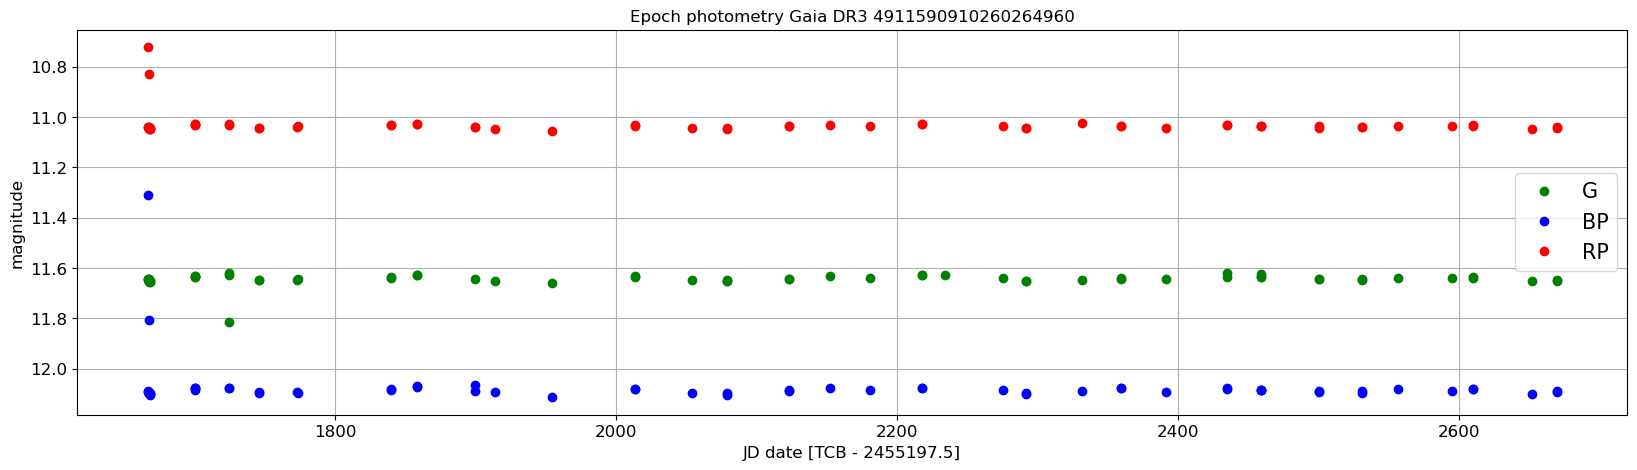

In [6]:
dl_key   = dl_keys[0]           # Select an element from the dl_keys() list displayed above
votable  = datalink[dl_key][0]  # Select the first (and only) element of the list

# Display VOTable metadata ================
print(f'File metadata:')
print('-' * 160)
for item in votable.iter_fields_and_params():
    print(item)

# Display VOTable data ====================
print(f'File data:')
print('-' * 160)
votable_data = votable.to_table()
display(votable_data[0:3])


source_id = votable.get_field_by_id('source_id').value

if 'EPOCH_PHOTOMETRY' in dl_key:
    title     = f'Epoch photometry Gaia DR3 {source_id}'
    plot_e_phot(votable_data, colours  = ['green', 'red', 'blue'], title = title, fontsize = 12, show_legend = True, show_grid = True, figsize = [20,5])
else:
    if 'RVS' or 'XP_SAMPLED' in dl_key:
        title     = f'Spectra: Gaia DR3 {source_id}'
        plot_sampled_spec(votable_data, title = title, fontsize = 12, show_legend = True, show_grid = True, figsize = [20,5], linewidth= 3)